In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
%matplotlib inline
sns.set_style('darkgrid')

In [38]:
df = pd.read_csv('sensor.csv')
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [39]:
df.shape

(220320, 55)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

In [41]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.machine_status = df.machine_status.astype('category')

In [42]:
df.set_index('timestamp', inplace=True)

In [43]:
df.index.is_unique

True

In [44]:
df.isnull().sum()

Unnamed: 0             0
sensor_00          10208
sensor_01            369
sensor_02             19
sensor_03             19
sensor_04             19
sensor_05             19
sensor_06           4798
sensor_07           5451
sensor_08           5107
sensor_09           4595
sensor_10             19
sensor_11             19
sensor_12             19
sensor_13             19
sensor_14             21
sensor_15         220320
sensor_16             31
sensor_17             46
sensor_18             46
sensor_19             16
sensor_20             16
sensor_21             16
sensor_22             41
sensor_23             16
sensor_24             16
sensor_25             36
sensor_26             20
sensor_27             16
sensor_28             16
sensor_29             72
sensor_30            261
sensor_31             16
sensor_32             68
sensor_33             16
sensor_34             16
sensor_35             16
sensor_36             16
sensor_37             16
sensor_38             27


In [45]:
df.drop(columns=['sensor_15'], inplace=True)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [46]:
df.index.max() - df.index.min()

Timedelta('152 days 23:59:00')

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


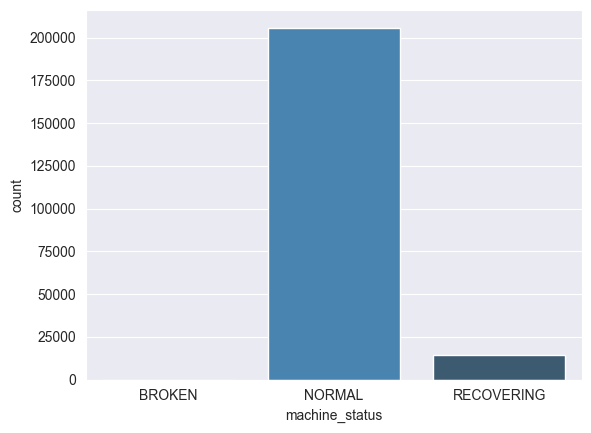

In [47]:
print(df.machine_status.value_counts())
sns.countplot(x='machine_status', data=df, hue='machine_status', palette='Blues_d', legend=False)
plt.show()

In [48]:
# the data is too big, so I divided it to 5 dataframe
df_1=df[['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04','sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09','machine_status']]
df_2=df[['sensor_10','sensor_11', 'sensor_12', 'sensor_13', 'sensor_14','sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20','machine_status']]
df_3=df[['sensor_21','sensor_22', 'sensor_23', 'sensor_24', 'sensor_25','sensor_26','sensor_27', 'sensor_28', 'sensor_29', 'sensor_30','sensor_31','machine_status']]
df_4=df[['sensor_32', 'sensor_33', 'sensor_34', 'sensor_35','sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40','sensor_41', 'sensor_42','machine_status']]
df_5=df[[ 'sensor_43','sensor_44', 'sensor_45','sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50','sensor_51','machine_status']]

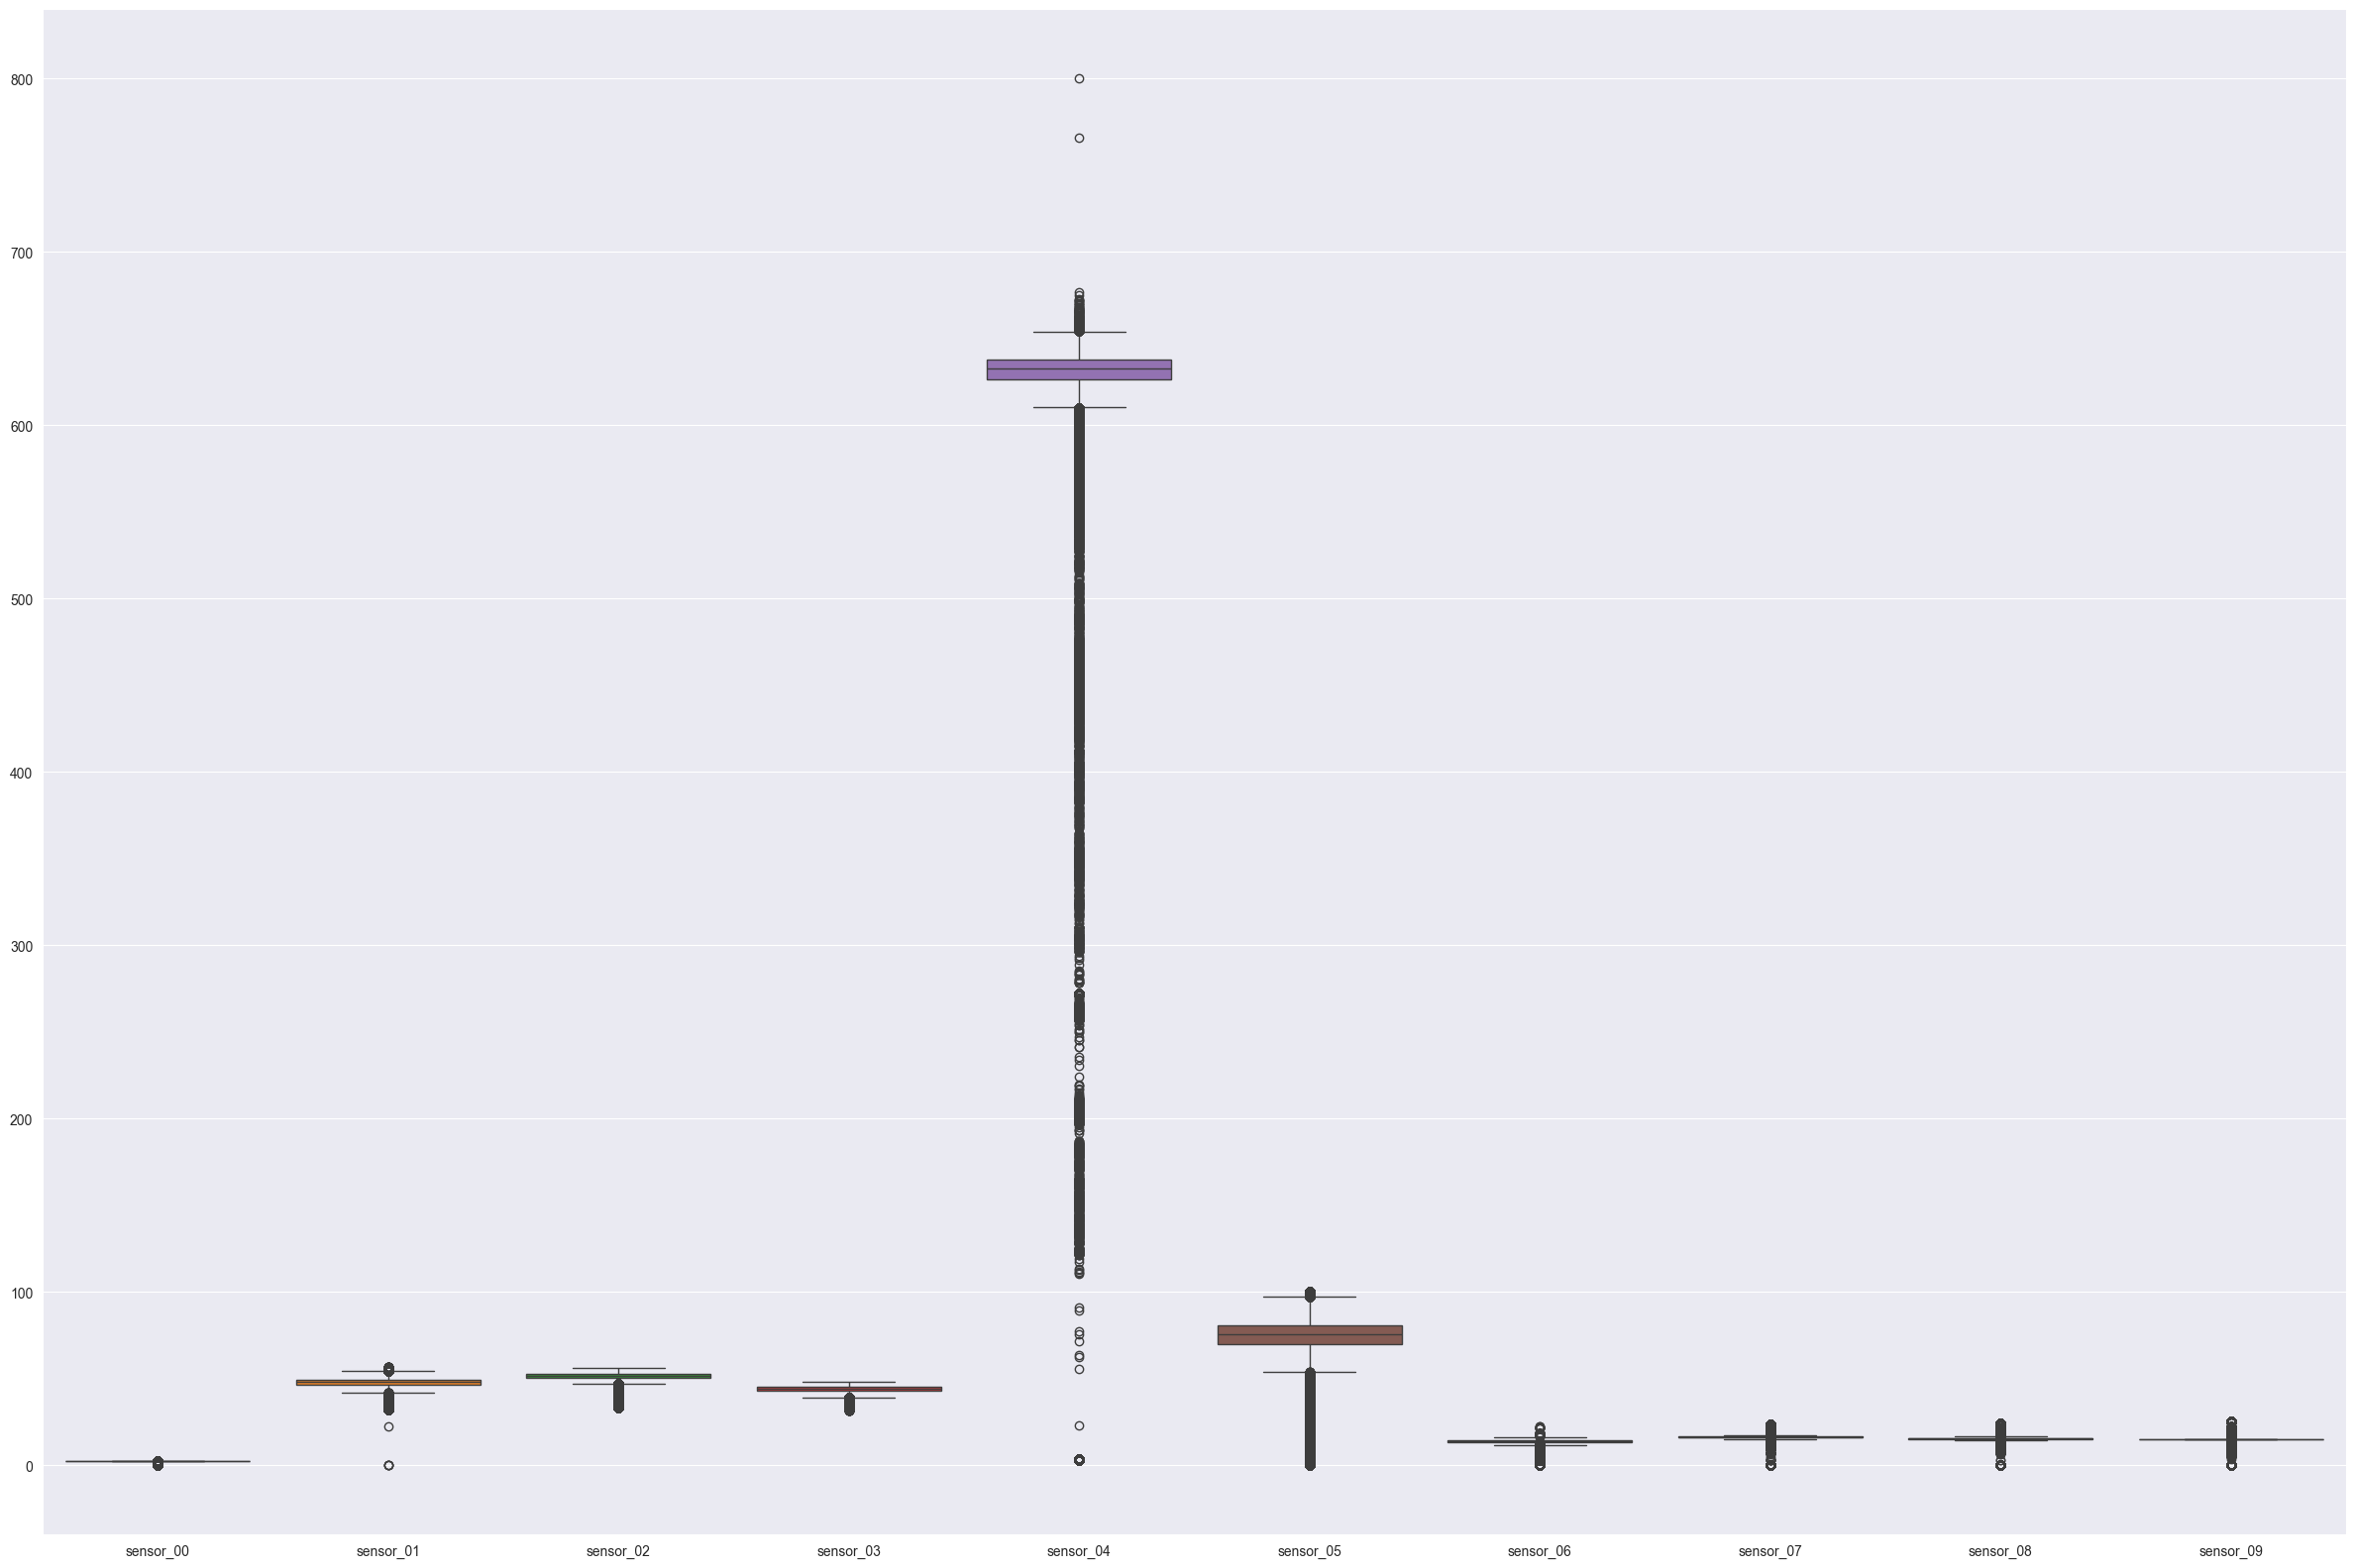

In [49]:
plt.figure(figsize=(30, 20))
sns.boxplot(data=df_1)
plt.show()

sensor_04 has high values than other sensors

In [50]:
df_1.describe()

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09
count,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,215725.000000
mean,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,14.799210
std,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,2.091963
min,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,0.000000
25%,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,15.053530
50%,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,15.082470
75%,2.499826,49.479160,52.777770,45.312500,637.615723,80.912150,14.539930,16.427950,15.697340,15.118630
max,2.549016,56.727430,56.032990,48.220490,800.000000,99.999880,22.251160,23.596640,24.348960,25.000000


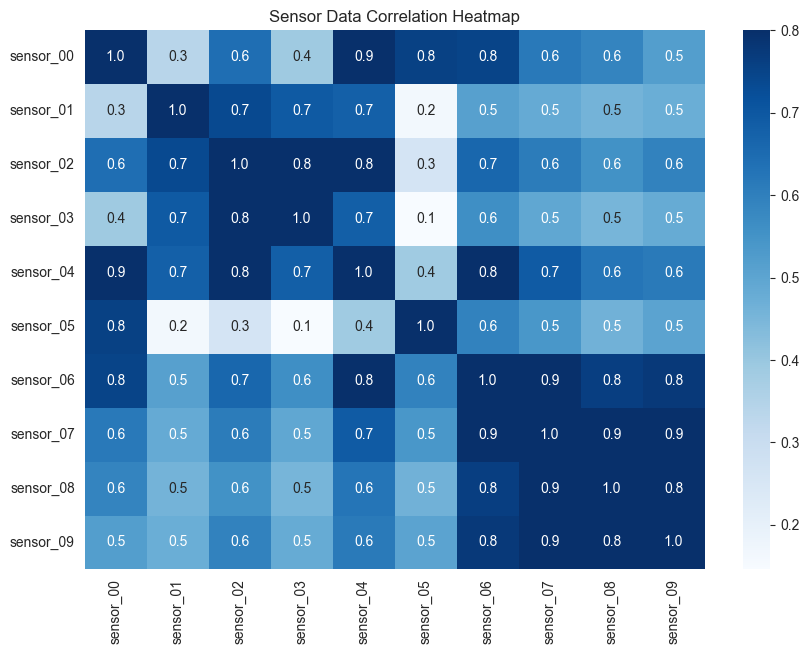

In [51]:
plt.figure(figsize=(10, 7))
correlation = df_1.corr(numeric_only=True)
sns.heatmap(correlation, cbar=True, fmt='.1f', vmax=0.8, annot=True, cmap='Blues')
plt.title('Sensor Data Correlation Heatmap')
plt.show()

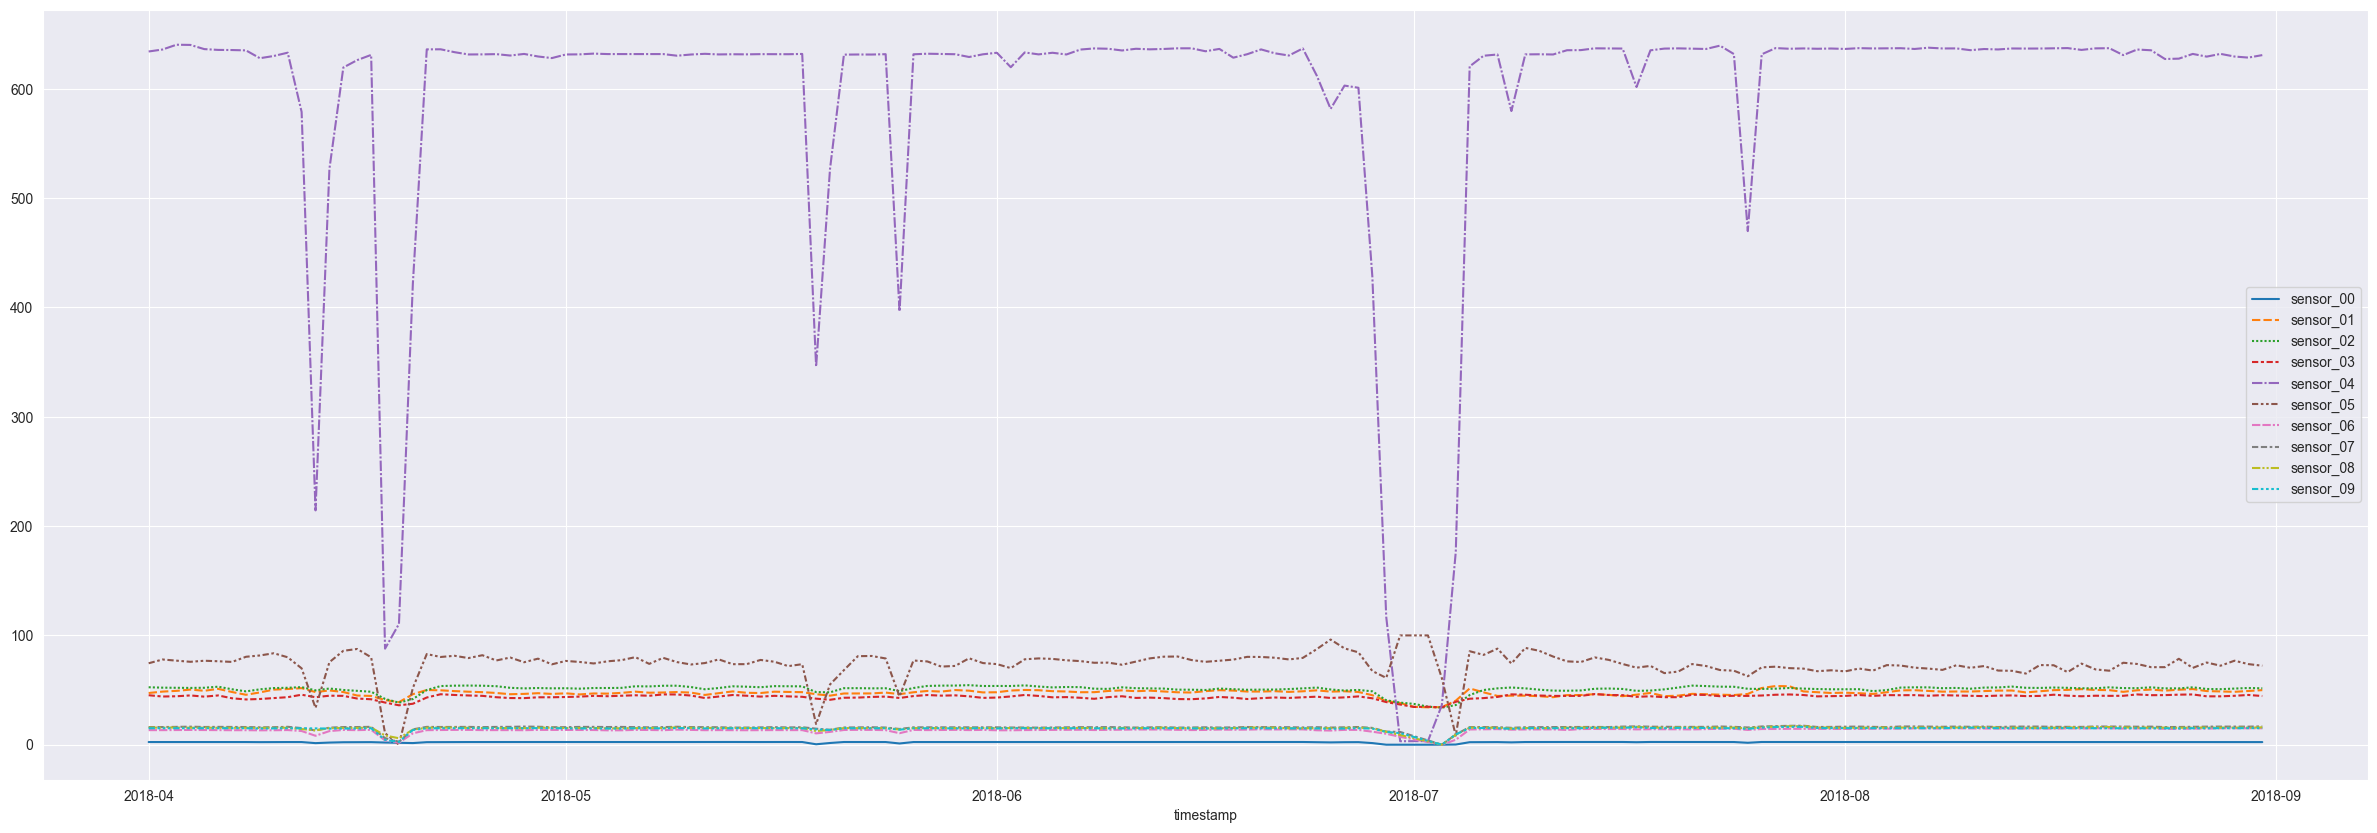

In [52]:
plt.figure(figsize=(30, 10))
sns.lineplot(data=df_1.resample('D').mean(numeric_only=True))
plt.show()

Values are decreased from April 10 to April 20, from May 15 to May 25, and from June 20 to July 20

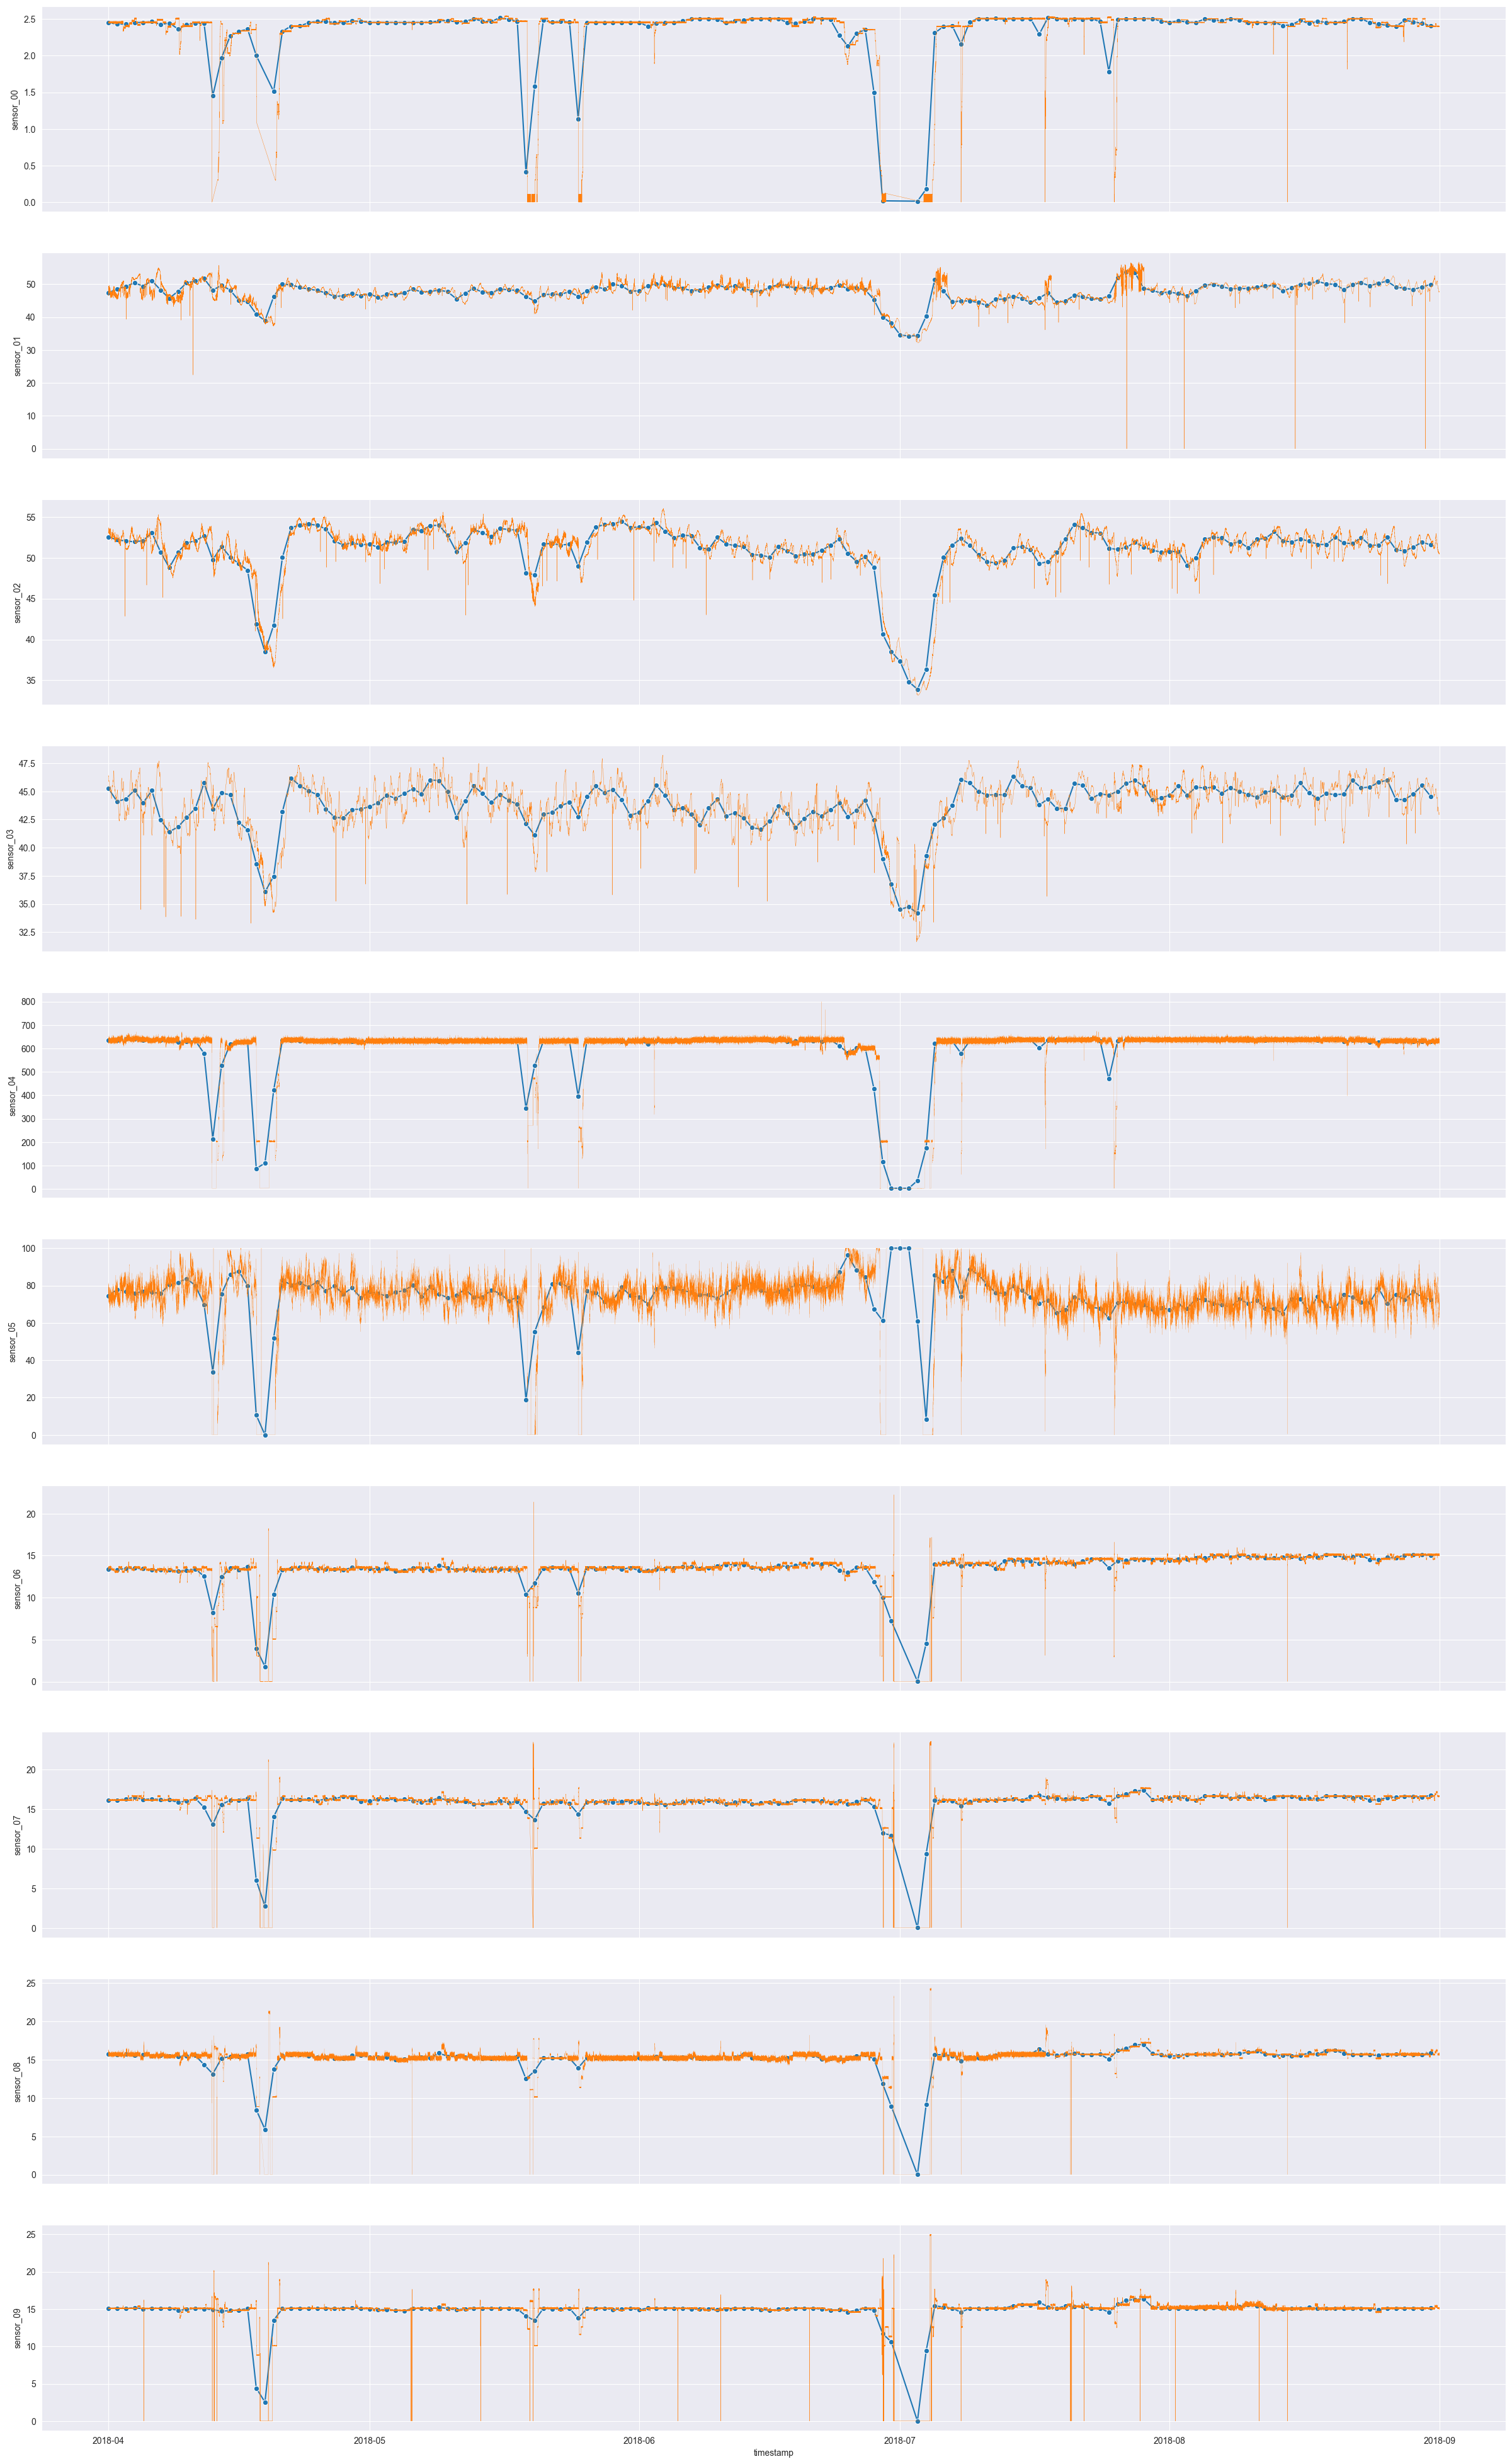

In [53]:
fig,ax=plt.subplots(ncols=1,nrows=10,sharex=True,figsize=(30,50))
sns.lineplot(data=df_1.sensor_00.resample('D').mean(),marker='o',ax=ax[0])
sns.lineplot(x=df_1.index,y='sensor_00',data=df_1,linewidth=0.3,ax=ax[0])
sns.lineplot(data=df_1.sensor_01.resample('D').mean(),marker='o',ax=ax[1])
sns.lineplot(x=df_1.index,y='sensor_01',data=df_1,linewidth=0.3,ax=ax[1])
sns.lineplot(data=df_1.sensor_02.resample('D').mean(),marker='o',ax=ax[2])
sns.lineplot(x=df_1.index,y='sensor_02',data=df_1,linewidth=0.3,ax=ax[2])
sns.lineplot(data=df_1.sensor_03.resample('D').mean(),marker='o',ax=ax[3])
sns.lineplot(x=df_1.index,y='sensor_03',data=df_1,linewidth=0.3,ax=ax[3])
sns.lineplot(data=df_1.sensor_04.resample('D').mean(),marker='o',ax=ax[4])
sns.lineplot(x=df_1.index,y='sensor_04',data=df_1,linewidth=0.1,ax=ax[4])
sns.lineplot(data=df_1.sensor_05.resample('D').mean(),marker='o',ax=ax[5])
sns.lineplot(x=df_1.index,y='sensor_05',data=df_1,linewidth=0.1,ax=ax[5])
sns.lineplot(data=df_1.sensor_06.resample('D').mean(),marker='o',ax=ax[6])
sns.lineplot(x=df_1.index,y='sensor_06',data=df_1,linewidth=0.2,ax=ax[6])
sns.lineplot(data=df_1.sensor_07.resample('D').mean(),marker='o',ax=ax[7])
sns.lineplot(x=df_1.index,y='sensor_07',data=df_1,linewidth=0.2,ax=ax[7])
sns.lineplot(data=df_1.sensor_08.resample('D').mean(),marker='o',ax=ax[8])
sns.lineplot(x=df_1.index,y='sensor_08',data=df_1,linewidth=0.1,ax=ax[8])
sns.lineplot(data=df_1.sensor_09.resample('D').mean(),marker='o',ax=ax[9])
sns.lineplot(x=df_1.index,y='sensor_09',data=df_1,linewidth=0.3,ax=ax[9])
plt.show()

All sensors have the same pattern but the values of the data are different.

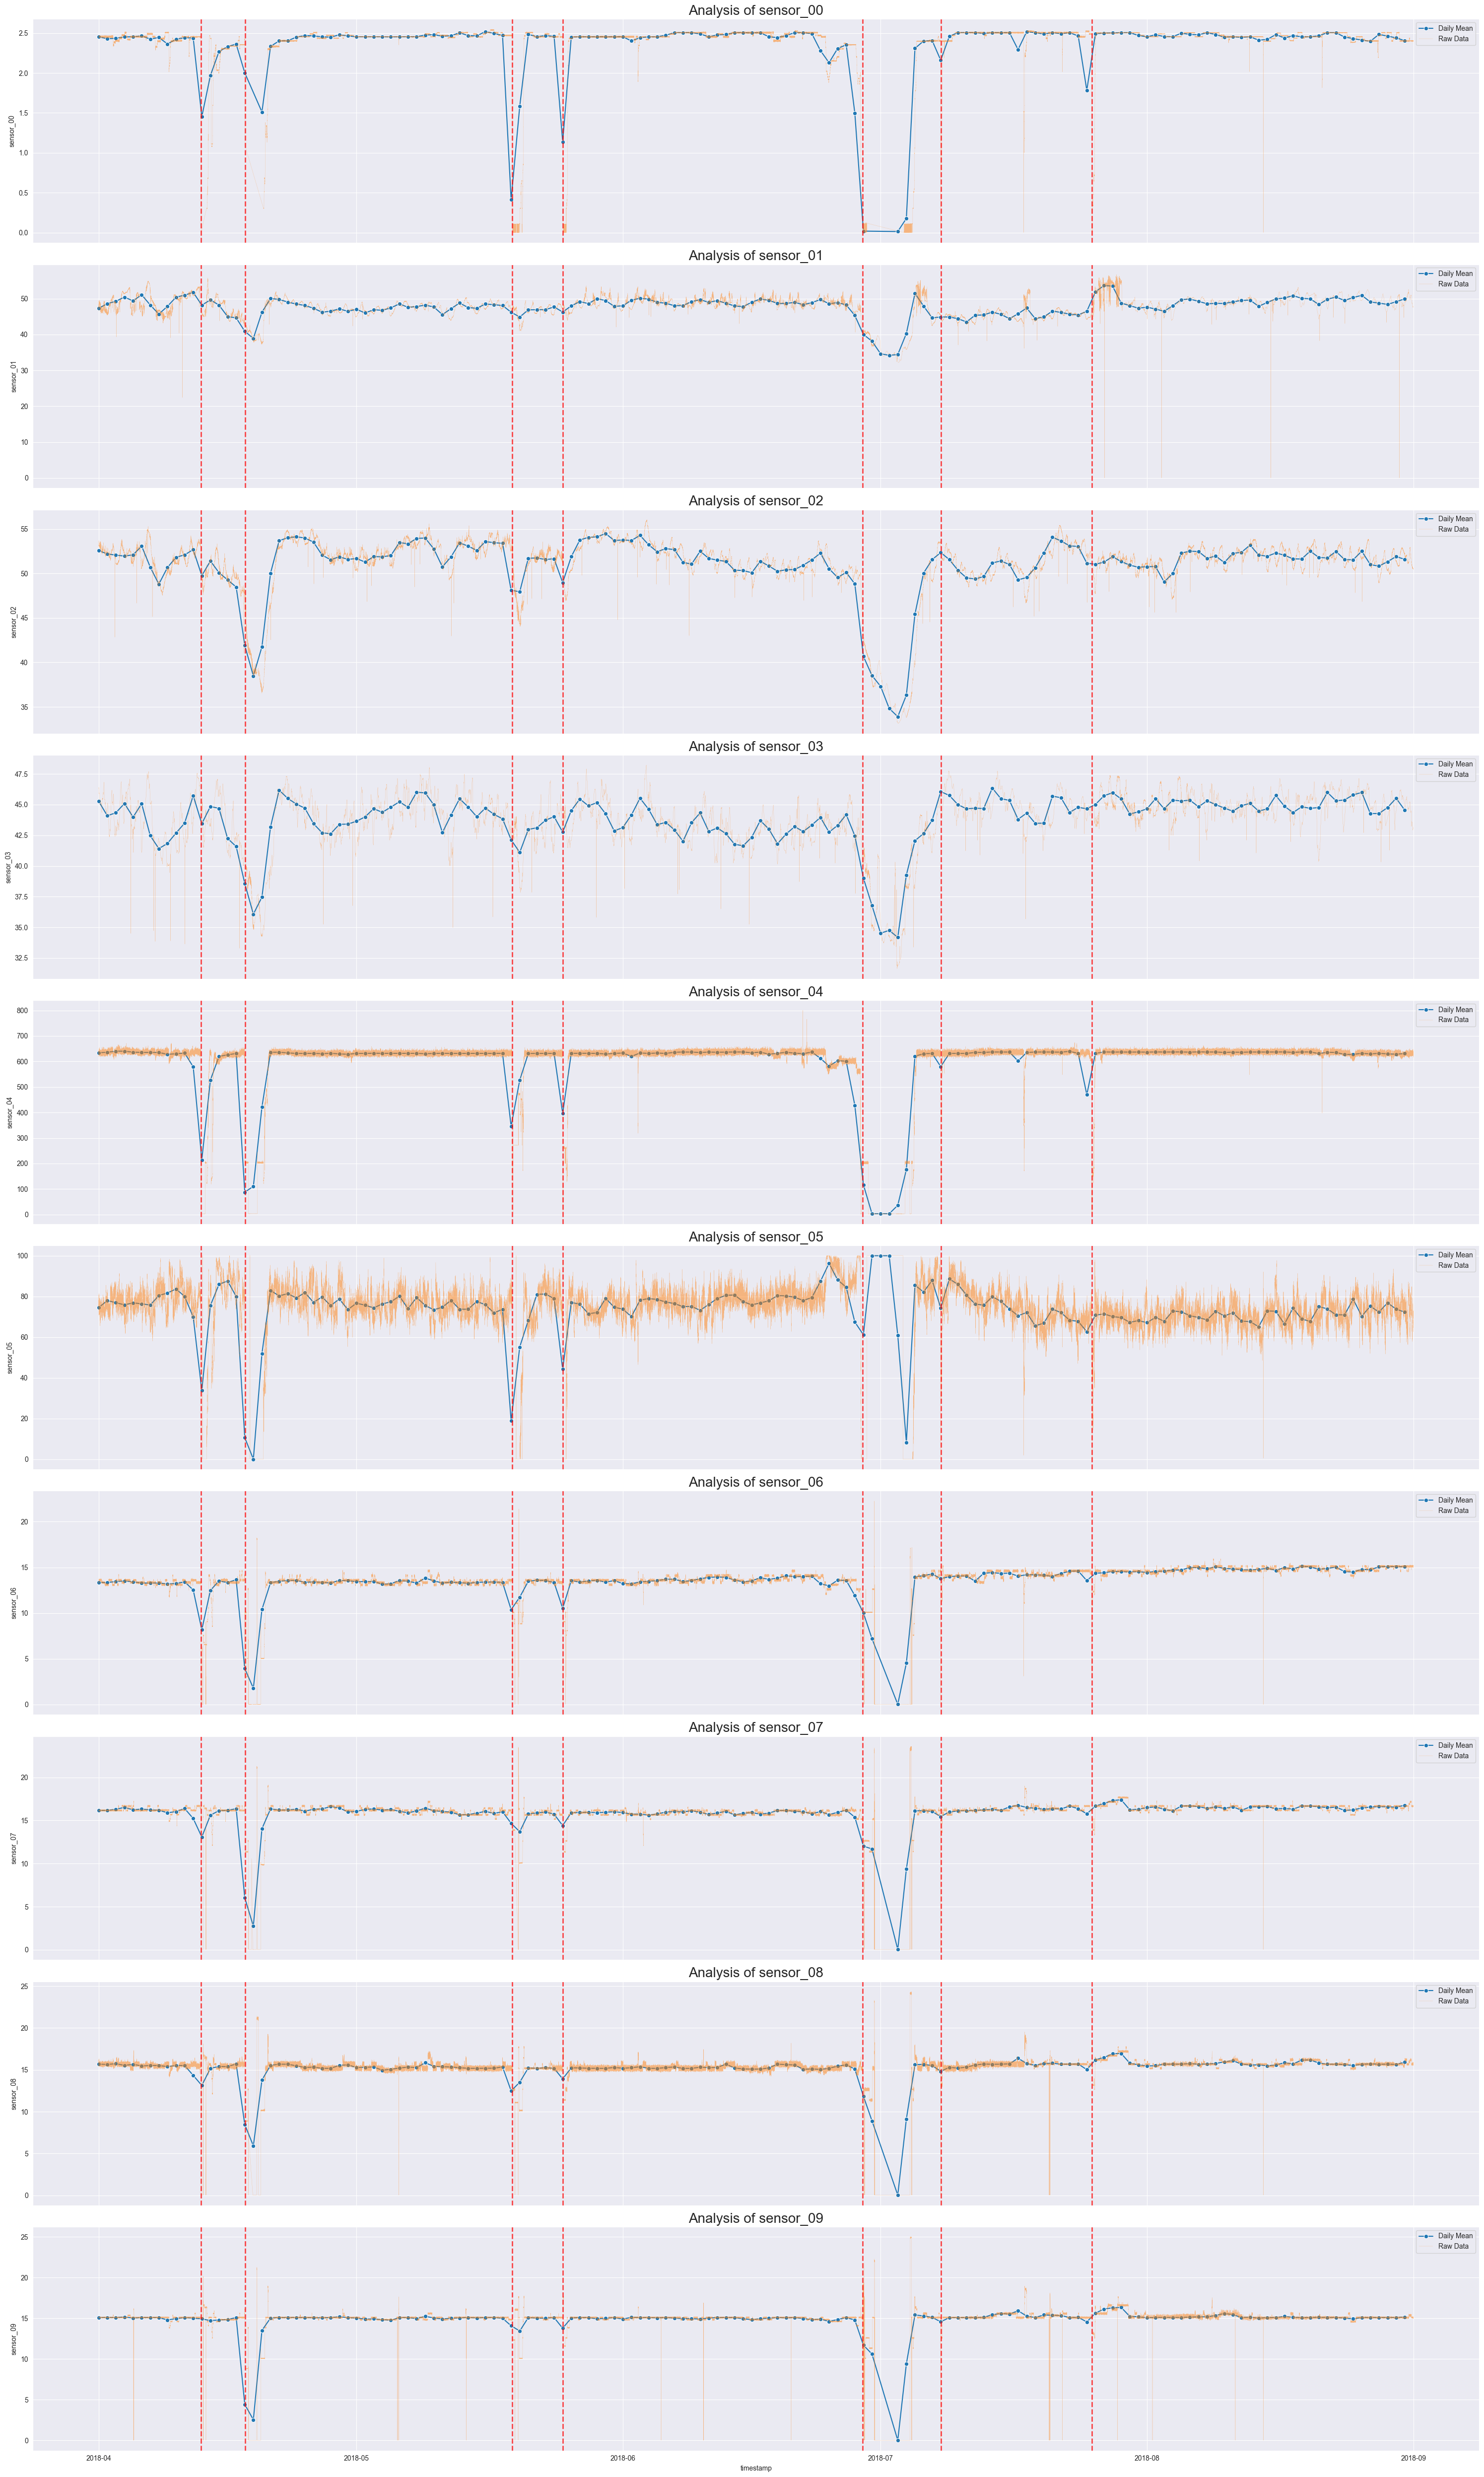

In [54]:
broken_periods = df_1[df_1['machine_status'] == 'BROKEN'].index

fig, ax = plt.subplots(ncols=1, nrows=10, sharex=True, figsize=(30, 50));
for i in range(10):
    sensor_name = f'sensor_{i:02d}'
    # daily average
    sns.lineplot(data=df_1[sensor_name].resample('D').mean(), marker='o', ax=ax[i], label='Daily Mean')
    # original data
    sns.lineplot(x=df_1.index, y=sensor_name, data=df_1, linewidth=0.2, ax=ax[i], alpha=0.5, label="Raw Data")

    for timestamp in broken_periods:
        ax[i].axvline(x=timestamp, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    ax[i].set_title(f'Analysis of {sensor_name}', fontsize=20)
    ax[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [55]:
df_1['target'] = 0
failure_starts = df_1[(df_1['machine_status'] == 'BROKEN') & (df_1['machine_status'].shift(1) != 'BROKEN')].index

window_size = pd.Timedelta(hours=24)
for fail_time in failure_starts:
    start_time = fail_time - window_size
    df_1.loc[(df_1.index >= start_time) & (df_1.index < fail_time), 'target'] = 1

print(df_1['target'].value_counts())

target
0    210240
1     10080
Name: count, dtype: int64


/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_24686/3765160209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['target'] = 0


In [61]:
df_cleaned = df_1[df_1['machine_status'] != 'RECOVERING']
df_final = df_cleaned.ffill()
df_final = df_final.bfill()


In [65]:
correlations = df_final.corr(numeric_only=True)['target'].sort_values(ascending=False)

print("Sensors with a high correlation with the target variable")
print(correlations.head(11))

Sensors with a high correlation with the target variable
target       1.000000
sensor_05    0.051373
sensor_08   -0.014104
sensor_09   -0.018231
sensor_02   -0.031820
sensor_07   -0.034736
sensor_03   -0.065478
sensor_06   -0.073064
sensor_00   -0.083572
sensor_04   -0.089461
sensor_01   -0.134889
Name: target, dtype: float64


In [81]:
tscv = TimeSeriesSplit(n_splits=5)

fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    n_ones = (y_test == 1).sum()
    print(f"\n--- Fold {fold} ---")
    print(f"Test set size: {len(y_test)} | Failures(1) in test set: {n_ones}")
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:, 1]
    threshold = 0.01
    y_pred = (y_probs >= threshold).astype(int)
    
    if n_ones > 0:
        print(f"--- [Custom Threshold: {threshold}] Evaluation ---")
        print(classification_report(y_test, y_pred))

    fold += 1


--- Fold 1 ---
Test set size: 34307 | Failures(1) in test set: 1440
--- [Custom Threshold: 0.01] Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.70      0.80     32867
           1       0.02      0.14      0.04      1440

    accuracy                           0.68     34307
   macro avg       0.48      0.42      0.42     34307
weighted avg       0.91      0.68      0.77     34307


--- Fold 2 ---
Test set size: 34307 | Failures(1) in test set: 1440
--- [Custom Threshold: 0.01] Evaluation ---
              precision    recall  f1-score   support

           0       0.92      0.47      0.62     32867
           1       0.01      0.10      0.02      1440

    accuracy                           0.45     34307
   macro avg       0.47      0.29      0.32     34307
weighted avg       0.88      0.45      0.60     34307


--- Fold 3 ---
Test set size: 34307 | Failures(1) in test set: 2880
--- [Custom Threshold: 0.01] Evaluation ---
       

In [87]:
sensor_cols = [col for col in df_final.columns if 'sensor' in col]

window_size = 360

for col in sensor_cols:
    df_final[f'{col}_mean_1h'] = df_final[col].rolling(window=window_size).mean()
    df_final[f'{col}_std_1h'] = df_final[col].rolling(window=window_size).std()

df_final = df_final.bfill()

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_24686/1943122642.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'{col}_mean_1h'] = df_final[col].rolling(window=window_size).mean()
/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_24686/1943122642.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'{col}_std_1h'] = df_final[col].rolling(window=window_size).std()
/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_24686/1943122642.py:6: PerformanceWarning: DataFrame is highly fr

In [88]:
X = df_final.drop(columns=['machine_status', 'target'])
y = df_final['target']

tscv = TimeSeriesSplit(n_splits=5)
fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    n_ones = (y_test == 1).sum()
    print(f"\n--- Fold {fold} (Features: {X_train.shape[1]}개) ---")
    print(f"Test set size: {len(y_test)} | Failures(1) in test set: {n_ones}")
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
    model.fit(X_train, y_train)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    threshold = 0.01
    y_pred = (y_probs >= threshold).astype(int)

    if n_ones > 0:
        print(f"--- [After Feature Engineering] Threshold: {threshold} ---")
        print(classification_report(y_test, y_pred))
    else:
        print(f"Warning: No failures in this fold. Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    fold += 1


--- Fold 1 (Features: 150개) ---
Test set size: 34307 | Failures(1) in test set: 1440
--- [After Feature Engineering] Threshold: 0.01 ---
              precision    recall  f1-score   support

           0       0.97      0.19      0.32     32867
           1       0.04      0.84      0.08      1440

    accuracy                           0.22     34307
   macro avg       0.50      0.52      0.20     34307
weighted avg       0.93      0.22      0.31     34307


--- Fold 2 (Features: 150개) ---
Test set size: 34307 | Failures(1) in test set: 1440
--- [After Feature Engineering] Threshold: 0.01 ---
              precision    recall  f1-score   support

           0       0.90      0.18      0.30     32867
           1       0.03      0.54      0.05      1440

    accuracy                           0.20     34307
   macro avg       0.46      0.36      0.18     34307
weighted avg       0.86      0.20      0.29     34307


--- Fold 3 (Features: 150개) ---
Test set size: 34307 | Failures(1) in

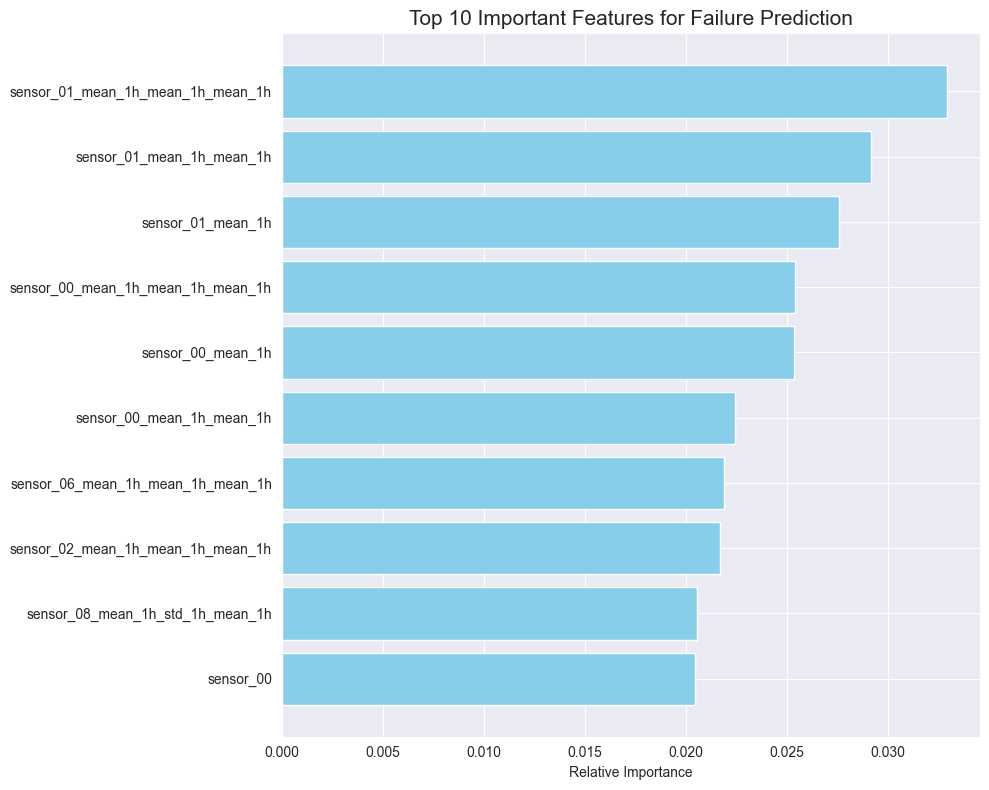

In [92]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] 

plt.figure(figsize=(10, 8))
plt.title('Top 10 Important Features for Failure Prediction', fontsize=15)
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()